DATA VISUALIZATION

1.0  VERTICAL BARCHART

In [7]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.5 MB 2.0 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.5 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.5 MB 2.7 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 2.8 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 2.2 MB/s eta 0:00:03
   -------------------- ------------------- 5

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os


In [12]:
os.getcwd()

'c:\\Users\\hp\\Desktop\\Workshop'

In [13]:
#LOAD THE DATASET
df=pd.read_excel("datasets/nyeri.xlsx")
df.head(5)

,student_name,student_class,student_course,student_year,student_gender,student_category,student_adm_no,attachment_period,year,attachment_start_date,attachment_end_date,company_name,sector_name,placement_status,graded,assigned_manual,student_workbehaviour_grading_score,student_skills_grading_score,student_knowledge_grading_score,student_final_score
0,Allan Thiga Maina,NNP/EIT4/25J1,ELECTRICAL INSTALLATION TECHNOLOGY,1.0,Male,CBS,54056,sept-dec,2025.0,2025-09-01,2025-12-31,SAMTECH ELECTRICALS,"Electrical & Electronics Engineering, Electric...",Placed,Not Graded,Assigned,10.0,38.6,NaN,NaN
1,Bernad Ndirangu Mwangi,NNP/EIT4/25J1,ELECTRICAL INSTALLATION TECHNOLOGY,1.0,Male,CBS,51732,sept-dec,2025.0,2025-09-01,2025-12-31,KARATINA SUBCOUNTY HOSPITAL,"HEALTH AND CARE, Health Care Giver, Healthcare...",Placed,Graded,Assigned,20.0,51.4,15.0,86.0
2,Isaac Kanja Kabuchu,NNP/EIT4/25J1,ELECTRICAL INSTALLATION TECHNOLOGY,1.0,Male,CBS,53862,sept-dec,2025.0,2025-09-01,2025-12-31,NYERI RURINGU,NaN,Placed,Not Graded,Assigned,NaN,NaN,NaN,NaN
3,Isaac Kihagi Biru,NNP/EIT4/25J1,ELECTRICAL INSTALLATION TECHNOLOGY,1.0,Male,CBS,51609,sept-dec,2025.0,2025-09-01,2025-12-31,KENYA POWER NYERI,"Electrical & Electronics Engineering, Electric...",Placed,Graded,Assigned,20.0,60.0,20.0,100.0
4,James Mugendi Mugi,NNP/EIT4/25J1,ELECTRICAL INSTALLATION TECHNOLOGY,1.0,Male,CBS,53842,sept-dec,2025.0,2025-09-01,2025-12-31,ITUMBE TEA FACTORY CO LTD,Electrical & Electronics Engineering,Placed,Graded,Assigned,20.0,42.9,16.7,80.0


In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17567 entries, 0 to 17566
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   student_name                         17567 non-null  object 
 1   student_class                        17567 non-null  str    
 2   student_course                       17566 non-null  str    
 3   student_year                         10470 non-null  float64
 4   student_gender                       16960 non-null  str    
 5   student_category                     17567 non-null  str    
 6   student_adm_no                       17567 non-null  object 
 7   attachment_period                    15151 non-null  str    
 8   year                                 15151 non-null  float64
 9   attachment_start_date                15151 non-null  str    
 10  attachment_end_date                  15151 non-null  str    
 11  company_name                         12

In [15]:
df["student_gender"].value_counts()


student_gender
Male       9932
Female     6078
F           278
MALE        229
M           184
FEMALE      129
male         92
female       32
Male          3
FEMale        1
FeMale        1
FE4MALE       1
Name: count, dtype: int64

In [17]:
string_columns = df.select_dtypes(include=["object", "string"]).columns

df[string_columns] = df[string_columns].apply(
    lambda x: x.str.upper()
)

In [18]:
df['student_gender'].value_counts()

student_gender
MALE       10253
FEMALE      6241
F            278
M            184
MALE           3
FE4MALE        1
Name: count, dtype: int64

In [23]:
df['student_gender'] = (
    df['student_gender']
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.upper()
    .replace({
        'F': 'FEMALE',
        'M': 'MALE',
        'FE4MALE': 'FEMALE'
    })
)

In [25]:
gender_count=df['student_gender'].value_counts()

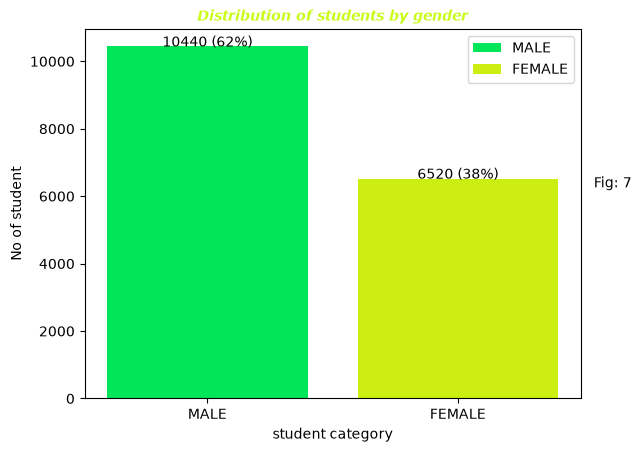

In [45]:
# DRAW THE CHART

plt.bar(
    gender_count.index,
    gender_count.values,
    color=['#00e658', '#cdee13']
)

plt.title(
    'Distribution of students by gender',
    color='#c9fa18',
    fontweight='bold',
    fontstyle='italic',
    fontsize=10,
    fontname='verdana'
)

plt.ylabel('No of student')
plt.xlabel('student category')

plt.figtext(0.98, 0.55, 'Fig: 7', ha='right')

colors = [
    Patch(facecolor='#00e658', label='MALE'),
    Patch(facecolor='#cdee13', label='FEMALE')
]

plt.legend(handles=colors)

for i, value in enumerate(gender_count.values):
    percentage = (value / gender_count.sum()) * 100
    plt.text(
        i,
        value,
        f'{value} ({percentage:.0f}%)',
        ha='center'
    )

plt.show()